In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("sales_data.xlsx")

df.head()

,Order_ID,Date,Customer,Product,Category,Region,Quantity,Unit_Price,Sales,Payment_Mode
0,1001,2026-03-20 00:00:00,Vikas Yadav,Laptop,Electronics,West,4.0,57750.0,231000.0,cash
1,1002,2026-04-05 00:00:00,Nitin Shah,Printer,Electronics,East,2.0,8100.0,16200.0,Cash
2,1003,2026-01-24 00:00:00,Manish Joshi,Tablet,Electronics,South,4.0,28000.0,112000.0,Debit Card
3,1004,2026-05-21 00:00:00,Pooja Jain,Keyboard,Accessories,South,1.0,2750.0,2750.0,Net Banking
4,1005,2026-02-10 00:00:00,Priya Verma,Monitor,Electronics,East,3.0,12000.0,36000.0,Net Banking


In [3]:
df.shape

(200, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      200 non-null    int64  
 1   Date          200 non-null    object 
 2   Customer      194 non-null    object 
 3   Product       200 non-null    object 
 4   Category      200 non-null    object 
 5   Region        194 non-null    object 
 6   Quantity      197 non-null    float64
 7   Unit_Price    200 non-null    float64
 8   Sales         193 non-null    float64
 9   Payment_Mode  196 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 15.8+ KB


In [5]:
df.isnull().sum()

Order_ID        0
Date            0
Customer        6
Product         0
Category        0
Region          6
Quantity        3
Unit_Price      0
Sales           7
Payment_Mode    4
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Customer
df["Customer"] = df["Customer"].fillna("Unknown")
df["Customer"] = df["Customer"].astype(str).str.strip().str.title()

# Product
df["Product"] = df["Product"].fillna("Unknown")
df["Product"] = df["Product"].astype(str).str.strip().str.title()

# Category
df["Category"] = df["Category"].fillna("Unknown")
df["Category"] = df["Category"].astype(str).str.strip().str.title()

# Region
df["Region"] = df["Region"].fillna("Unknown")
df["Region"] = df["Region"].astype(str).str.strip().str.title()

# Payment Mode
df["Payment_Mode"] = df["Payment_Mode"].fillna("Unknown")
df["Payment_Mode"] = df["Payment_Mode"].astype(str).str.strip().str.title()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [10]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Invalid dates:", df["Date"].isnull().sum())

Invalid dates: 6


In [11]:
df = df.dropna(subset=["Date"])

print("Invalid dates removed.")

Invalid dates removed.


In [12]:
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Unit_Price"] = pd.to_numeric(
    df["Unit_Price"],
    errors="coerce"
)

df["Sales"] = pd.to_numeric(
    df["Sales"],
    errors="coerce"
)

print("Numeric columns converted successfully.")

Numeric columns converted successfully.


In [13]:
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

df["Unit_Price"] = df["Unit_Price"].fillna(
    df["Unit_Price"].median()
)

df["Sales"] = df["Sales"].fillna(
    df["Sales"].median()
)

print("Missing numeric values handled.")

Missing numeric values handled.


In [14]:
print("Negative Quantity:")
print((df["Quantity"] < 0).sum())

print("\nNegative Sales:")
print((df["Sales"] < 0).sum())

Negative Quantity:
4

Negative Sales:
4


In [15]:
df = df[df["Quantity"] > 0]
df = df[df["Sales"] >= 0]

print("Invalid negative values removed.")

Invalid negative values removed.


In [16]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

df.head()

Final Dataset Shape: (181, 10)

Missing Values:
Order_ID        0
Date            0
Customer        0
Product         0
Category        0
Region          0
Quantity        0
Unit_Price      0
Sales           0
Payment_Mode    0
dtype: int64

Duplicates:
0


,Order_ID,Date,Customer,Product,Category,Region,Quantity,Unit_Price,Sales,Payment_Mode
0,1001,2026-03-20,Vikas Yadav,Laptop,Electronics,West,4.0,57750.0,231000.0,Cash
1,1002,2026-04-05,Nitin Shah,Printer,Electronics,East,2.0,8100.0,16200.0,Cash
2,1003,2026-01-24,Manish Joshi,Tablet,Electronics,South,4.0,28000.0,112000.0,Debit Card
3,1004,2026-05-21,Pooja Jain,Keyboard,Accessories,South,1.0,2750.0,2750.0,Net Banking
4,1005,2026-02-10,Priya Verma,Monitor,Electronics,East,3.0,12000.0,36000.0,Net Banking


In [17]:
total_sales = df["Sales"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order_ID"].nunique()
average_sales = df["Sales"].mean()

print("========== SALES KPIs ==========")
print("Total Sales:", round(total_sales, 2))
print("Total Quantity:", int(total_quantity))
print("Total Orders:", total_orders)
print("Average Sales per Order:", round(average_sales, 2))

========== SALES KPIs ==========
Total Sales: 6234032.5
Total Quantity: 532
Total Orders: 181
Average Sales per Order: 34442.17


In [18]:
region_report = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region_report

,Region,Sales
0,West,2389532.5
1,North,1490950.0
2,East,1214892.5
3,South,965687.5
4,Unknown,172970.0


In [19]:
product_report = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_report

,Product,Sales
0,Tablet,1828362.5
1,Laptop,1778512.5
2,Monitor,718962.5
3,Mobile,595962.5
4,Printer,541362.5
5,Headphones,274637.5
6,Webcam,229950.0
7,Keyboard,151212.5
8,Mouse,58850.0
9,Usb Drive,56220.0


In [20]:
customer_report = (
    df.groupby("Customer")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_report

,Customer,Sales
0,Amit Kumar,577915.0
1,Sneha Patel,569362.5
2,Priya Verma,540387.5
3,Manish Joshi,517612.5
4,Rahul Sharma,504315.0
5,Nitin Shah,459132.5
6,Unknown,451000.0
7,Vikas Yadav,445052.5
8,Arjun Malhotra,411125.0
9,Karan Kapoor,322135.0


In [21]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_report = (
    df.groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_report

,Month,Sales
0,2026-01,853695.0
1,2026-02,564975.0
2,2026-03,1176722.5
3,2026-04,915810.0
4,2026-05,1197175.0
5,2026-06,1525655.0


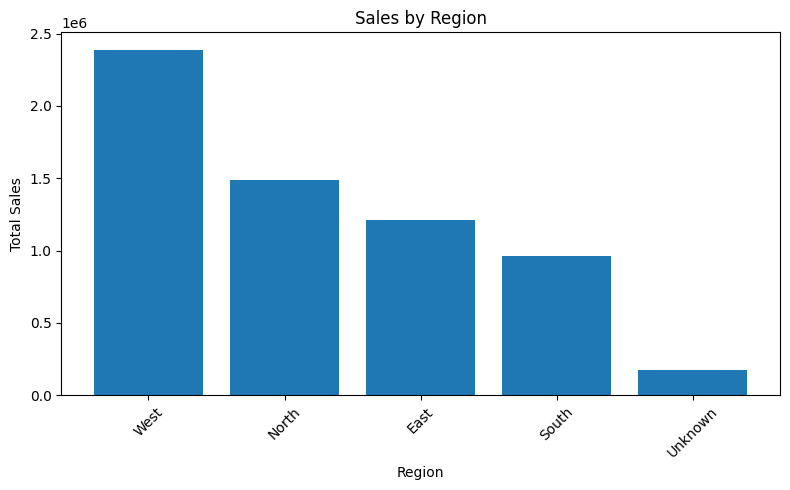

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_report["Region"],
    region_report["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

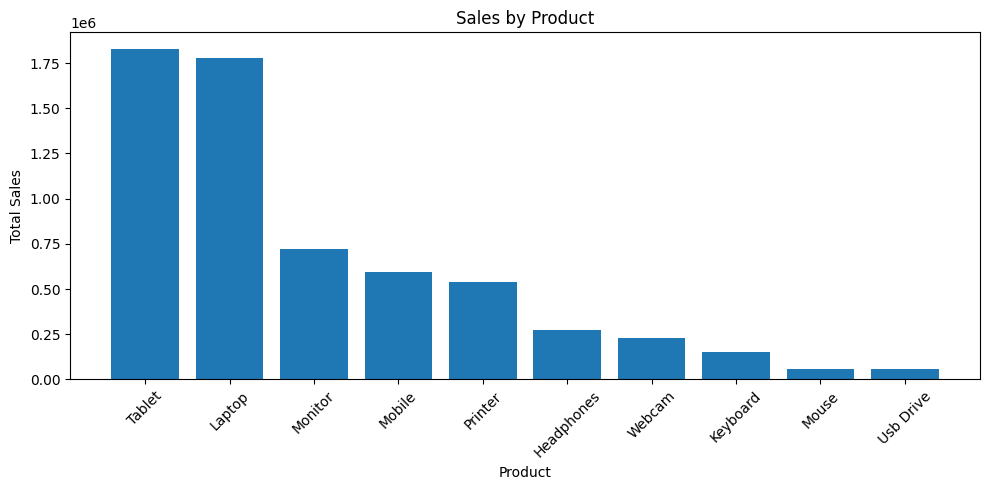

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_report["Product"],
    product_report["Sales"]
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

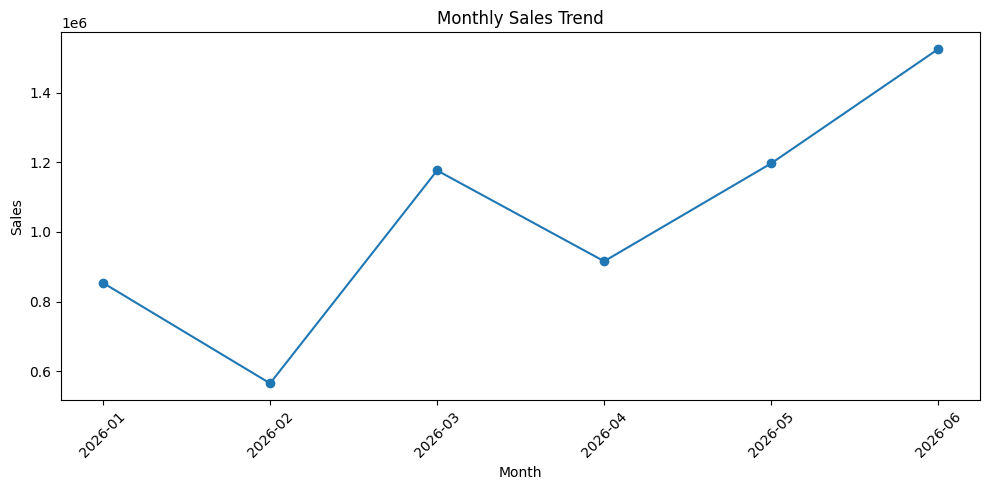

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_report["Month"],
    monthly_report["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
with pd.ExcelWriter(
    "automated_sales_report.xlsx",
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    region_report.to_excel(
        writer,
        sheet_name="Region Report",
        index=False
    )

    product_report.to_excel(
        writer,
        sheet_name="Product Report",
        index=False
    )

    customer_report.to_excel(
        writer,
        sheet_name="Customer Report",
        index=False
    )

    monthly_report.to_excel(
        writer,
        sheet_name="Monthly Report",
        index=False
    )

print("================================")
print("REPORT GENERATED SUCCESSFULLY!")
print("File: automated_sales_report.xlsx")
print("================================")

REPORT GENERATED SUCCESSFULLY!
File: automated_sales_report.xlsx


In [26]:
print("========== FINAL PROJECT SUMMARY ==========")

print("Original Rows: 200")
print("Final Rows:", len(df))
print("Columns:", len(df.columns))

print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Orders:", df["Order_ID"].nunique())
print("Total Quantity:", int(df["Quantity"].sum()))

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nProject Completed Successfully! ✅")

========== FINAL PROJECT SUMMARY ==========
Original Rows: 200
Final Rows: 181
Columns: 11
Total Sales: 6234032.5
Total Orders: 181
Total Quantity: 532

Missing Values:
0

Duplicate Rows:
0

Project Completed Successfully! ✅
